In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joint_index,
                                     animate_joint_index)
from sklearn.decomposition import PCA
import joblib
import os

In [3]:
def load_data(CASE, FOLDER, MODEL, TRIAL, BASE_PATH):
    data = []
    for trial in TRIAL:
        data_path = os.path.join(BASE_PATH, FOLDER, CASE, f'{MODEL}-pos_act_model0_buffer-{trial}.json')
        with open(data_path, "r") as file:
            data.append(json.load(file))
    return np.array(data)


In [14]:
CASE = 'flat'
FOLDER = 'cot'
TRIAL = [0,1,2,3,4,]
# TRIAL = [99,100]
MODEL = "hebb"
BASE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\logs'

flat_hebb = load_data("flat", FOLDER, "hebb", TRIAL, BASE_PATH)
flat_ff = load_data("flat", FOLDER, "ff", TRIAL, BASE_PATH)

# s15lr_hebb = load_data("s15lr", FOLDER, "hebb", TRIAL, BASE_PATH)
# s15lr_ff = load_data("s15lr", FOLDER, "ff", TRIAL, BASE_PATH)

s20l_hebb = load_data("s20l", FOLDER, "hebb", TRIAL, BASE_PATH)
s20l_ff = load_data("s20l", FOLDER, "ff", TRIAL, BASE_PATH)

In [6]:
# ---------
GECKO_MASS = 2.45 # kg
DISTANCE = 1.5 # m

# ---------
RAW_TO_CURRENT = 2.69 # mA
TORQUE_CONSTANT =  0.5494505495
IDLE_CURRENT = 0.0 # 0.18

# current = TORQUE_CONSTANT * torque + IDLE_CURRENT
# torque  = (current - IDLE_CURRENT) / TORQUE_CONSTANT

# -----------

RAW_TO_RPM = 0.229
RPM_TO_RADPS = 2 * np.pi / 60

In [15]:
def calculate_cot(data, index , mass, distance):
#     current = np.abs(np.array(data[index]['current']) * RAW_TO_CURRENT)/1000.0 # A
#     torque = np.abs((current - IDLE_CURRENT) / TORQUE_CONSTANT) # convert current to torque
    current = (np.array(data[index]['current']) * RAW_TO_CURRENT)/1000.0 # A
    torque = (current - IDLE_CURRENT) / TORQUE_CONSTANT # convert current to torque

    radps = (np.array(data[index]['vel'])) * RAW_TO_RPM * RPM_TO_RADPS # rad/s

    # voltage = np.array(data[index]['voltage']) * 0.1 # V
    
    power = np.abs(torque * radps) # W
    # power = (torque * radps) # W
    # power = np.maximum(torque * radps, 0) # W
    # power = np.abs(voltage) * np.abs(current)
    # power = np.abs(voltage* current)

    

    energy = np.sum(np.sum(power,axis=1) * np.array(data[index]['dt'])) # J
    # energy = power.sum(axis=1).mean()

    cot = energy / (mass * 9.81 * distance) # J/kg/m
    return cot

# cot = calculate_cot(data, 0, GECKO_MASS, DISTANCE)


In [16]:
cot_hebb_flat = np.array([calculate_cot(flat_hebb, i, GECKO_MASS, DISTANCE) for i in range(len(flat_hebb))])
cot_ff_flat = np.array([calculate_cot(flat_ff, i, GECKO_MASS, DISTANCE) for i in range(len(flat_ff))])

print(cot_hebb_flat , cot_ff_flat)
# cot_hebb_s15lr = np.array([calculate_cot(s15lr_hebb, i, GECKO_MASS, DISTANCE) for i in range(len(s15lr_hebb))])
# cot_ff_s15lr = np.array([calculate_cot(s15lr_ff, i, GECKO_MASS, DISTANCE) for i in range(len(s15lr_ff))])

cot_hebb_s20l = np.array([calculate_cot(s20l_hebb, i, GECKO_MASS, DISTANCE) for i in range(len(s20l_hebb))])
cot_ff_s20l = np.array([calculate_cot(s20l_ff, i, GECKO_MASS, DISTANCE) for i in range(len(s20l_ff))])


[1.45103735 1.56550176 1.5190723  1.52468518 1.35575533] [1.4690929  1.77748336 1.48817317 1.65630291 1.53134558]


In [11]:
from scipy import stats

def mean_ci95(x):
    x = np.asarray(x)
    n = len(x)
    m = x.mean()
    sem = x.std(ddof=1) / np.sqrt(n)
    h = sem * stats.t.ppf(0.975, n - 1)  # 95% CI half-width, n=10 -> t~2.26
    return m, h

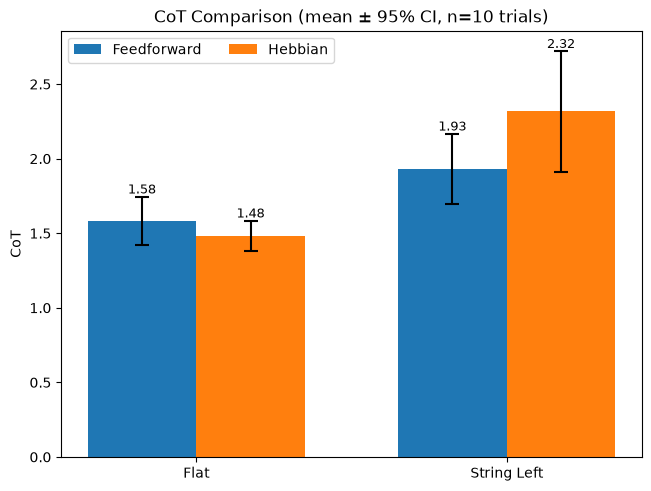

In [17]:
case = ("Flat",  "String Left")
groups = {
    # 'Feedforward': [cot_ff_flat, cot_ff_s15lr, cot_ff_s20l],
    # 'Hebbian':     [cot_hebb_flat, cot_hebb_s15lr, cot_hebb_s20l],
    'Feedforward': [cot_ff_flat , cot_ff_s20l],
    'Hebbian':     [cot_hebb_flat , cot_hebb_s20l],
}

x = np.arange(len(case))
width = 0.35

fig, ax = plt.subplots(layout='constrained')
for i, (label, arrs) in enumerate(groups.items()):
    means, halfwidths = zip(*(mean_ci95(a) for a in arrs))
    offset = (i - (len(groups) - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, yerr=halfwidths, capsize=5,
                   label=label, error_kw=dict(elinewidth=1.5, capthick=1.5))
    for xi, m, h in zip(x + offset, means, halfwidths):
        ax.text(xi, m + h, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x, case)
ax.set_ylabel('CoT')
ax.set_title('CoT Comparison (mean ± 95% CI, n=10 trials)')
ax.legend(loc='upper left', ncols=2)

plt.show()
